In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Filtered_TitleV_Permits.csv")



In [13]:
# Parse dates 
df["Date Received"] = pd.to_datetime(df["Date Received"], errors="coerce")
df["Date Disposed"] = pd.to_datetime(df["Date Disposed"], errors="coerce")

In [14]:
# Compute backlog (18 months rounded to 548 days)
df["processing_days"] = (df["Date Disposed"] - df["Date Received"]).dt.days
df["backlogged"] = df["processing_days"] > 548
df["Disposition Year"] = df["Date Disposed"].dt.year

In [15]:
# Aggregate data by Year AND Region
regional_backlog = (
    df[df["backlogged"]]
    .dropna(subset=["Disposition Year", "Region"])
    .groupby(["Disposition Year", "Region"])
    .size()
    .unstack(fill_value=0) # This turns regions into individual columns for plotting
)

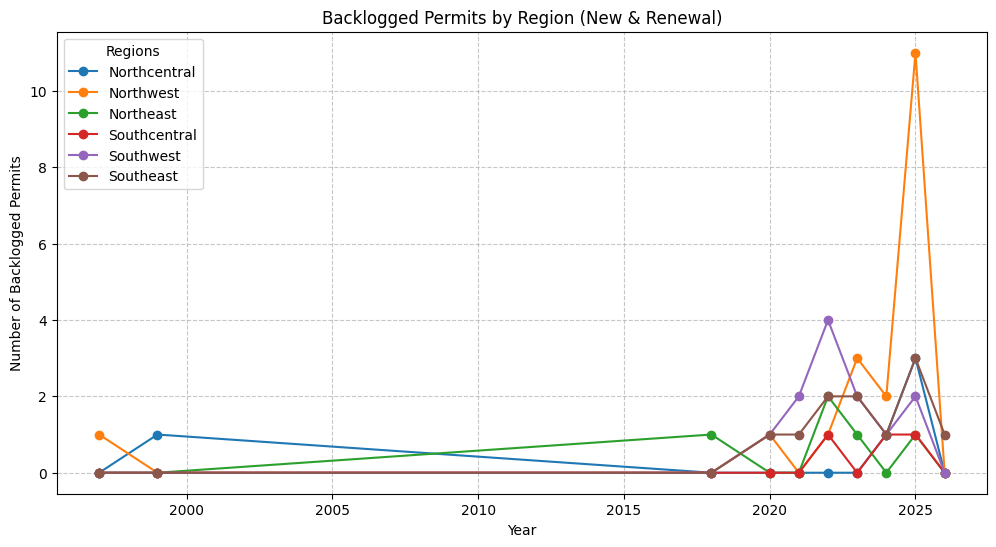

In [16]:
# Classify backlogged permits by Region
regions = ["Northcentral", "Northwest", "Northeast", "Southcentral", "Southwest", "Southeast"]

plt.figure(figsize=(12, 6))
for region in regions:
    if region in regional_backlog.columns:
        plt.plot(regional_backlog.index, regional_backlog[region], marker='o', label=region)

# Visualize line chart 
plt.title("Backlogged Permits by Region (New & Renewal)")
plt.xlabel("Year")
plt.ylabel("Number of Backlogged Permits")
plt.legend(title="Regions")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()